In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import os
import joblib

warnings.filterwarnings('ignore')

import shap
from lime import lime_tabular
from sklearn.model_selection import train_test_split

# ── Reproducibility ──────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Output directories ───────────────────────────────────────────────────────
for path in [
    'outputs/shap/ckd',
    'outputs/shap/diabetes',
    'outputs/lime/ckd',
    'outputs/lime/diabetes',
    'outputs/comparison'
]:
    os.makedirs(path, exist_ok=True)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

print('All imports successful.')
print('Output directories created.')

All imports successful.
Output directories created.


In [3]:
# ── Load cleaned CKD dataset ─────────────────────────────────────────────────
ckd_df = pd.read_csv('../data/chronic_kidney_disease/ckd_cleaned.csv')

print('CKD dataset shape:', ckd_df.shape)
print('\nColumns:', ckd_df.columns.tolist())
display(ckd_df.head(3))

CKD dataset shape: (400, 25)

Columns: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane', 'classification']


,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,48.0,80.0,1.02,1.0,0.0,0.0,0.0,0.0,0.0,121.0,...,44.0,7800.0,5.2,1.0,1.0,0.0,0.0,0.0,0.0,1
1,7.0,50.0,1.02,4.0,0.0,0.0,0.0,0.0,0.0,121.0,...,38.0,6000.0,4.8,0.0,0.0,0.0,0.0,0.0,0.0,1
2,62.0,80.0,1.01,2.0,3.0,0.0,0.0,0.0,0.0,423.0,...,31.0,7500.0,4.8,0.0,1.0,0.0,1.0,0.0,1.0,1


In [4]:
# ── Features / target split (same as Notebook 02) ───────────────────────────
X_ckd = ckd_df.drop(columns=['classification'])
y_ckd = ckd_df['classification']

X_ckd_train, X_ckd_test, y_ckd_train, y_ckd_test = train_test_split(
    X_ckd, y_ckd,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_ckd
)

print(f'CKD  Train: {X_ckd_train.shape[0]} rows  |  Test: {X_ckd_test.shape[0]} rows')
print(f'CKD features: {X_ckd.columns.tolist()}')

CKD  Train: 320 rows  |  Test: 80 rows
CKD features: ['age', 'bp', 'sg', 'al', 'su', 'rbc', 'pc', 'pcc', 'ba', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


In [5]:
# ── Load trained CKD pipeline (XGBoost best model from Notebook 02) ──────────
xgb_ckd_pipeline = joblib.load('outputs/xgb_pipeline.pkl')

print('CKD pipeline loaded:')
print(xgb_ckd_pipeline)

# ── Extract the XGBoost classifier step ──────────────────────────────────────
clf_ckd = xgb_ckd_pipeline.named_steps['classifier']
print('\nClassifier step extracted:', type(clf_ckd).__name__)

CKD pipeline loaded:
Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=0.8, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=n

In [6]:
# ── Identify representative patients in the test set ─────────────────────────
# We use the full pipeline for predicting so preprocessing is applied correctly
y_ckd_pred = xgb_ckd_pipeline.predict(X_ckd_test)
y_ckd_prob = xgb_ckd_pipeline.predict_proba(X_ckd_test)[:, 1]

# Pick the HIGH-risk patient with the highest predicted probability
high_mask = y_ckd_pred == 1
ckd_high_idx = np.where(high_mask)[0][np.argmax(y_ckd_prob[high_mask])]

# Pick the LOW-risk patient with the lowest predicted probability
low_mask = y_ckd_pred == 0
ckd_low_idx = np.where(low_mask)[0][np.argmin(y_ckd_prob[low_mask])]

print(f'CKD HIGH-risk patient  → test index {ckd_high_idx}  | predicted prob = {y_ckd_prob[ckd_high_idx]:.4f}')
print(f'CKD LOW-risk  patient  → test index {ckd_low_idx}   | predicted prob = {y_ckd_prob[ckd_low_idx]:.4f}')

CKD HIGH-risk patient  → test index 25  | predicted prob = 0.9984
CKD LOW-risk  patient  → test index 49   | predicted prob = 0.0028


## SHAP: CKD

SHAP (SHapley Additive exPlanations) assigns each feature a contribution score based on Shapley values from cooperative game theory.  
`TreeExplainer` is used here because XGBoost is a tree-based model — it is exact and fast (no sampling).

In [7]:
# ── Compute SHAP values on the test set ──────────────────────────────────────
# TreeExplainer works directly on the XGBoost classifier (not the full pipeline)
# Because the pipeline's scaler and SMOTE only affect training; at inference time
# the data flows through scaler → classifier. We pass the *original* test features
# because our pipeline's scaler is fit, and SHAP will use the classifier internally.
# For interpretability we want original feature values visible on plots.

shap_explainer_ckd = shap.TreeExplainer(clf_ckd)
shap_values_ckd = shap_explainer_ckd.shap_values(X_ckd_test)

print('SHAP values computed for CKD.')
print('Shape:', np.array(shap_values_ckd).shape)
print('Expected value (base rate):', round(shap_explainer_ckd.expected_value, 4))

SHAP values computed for CKD.
Shape: (80, 24)
Expected value (base rate): 0.1528


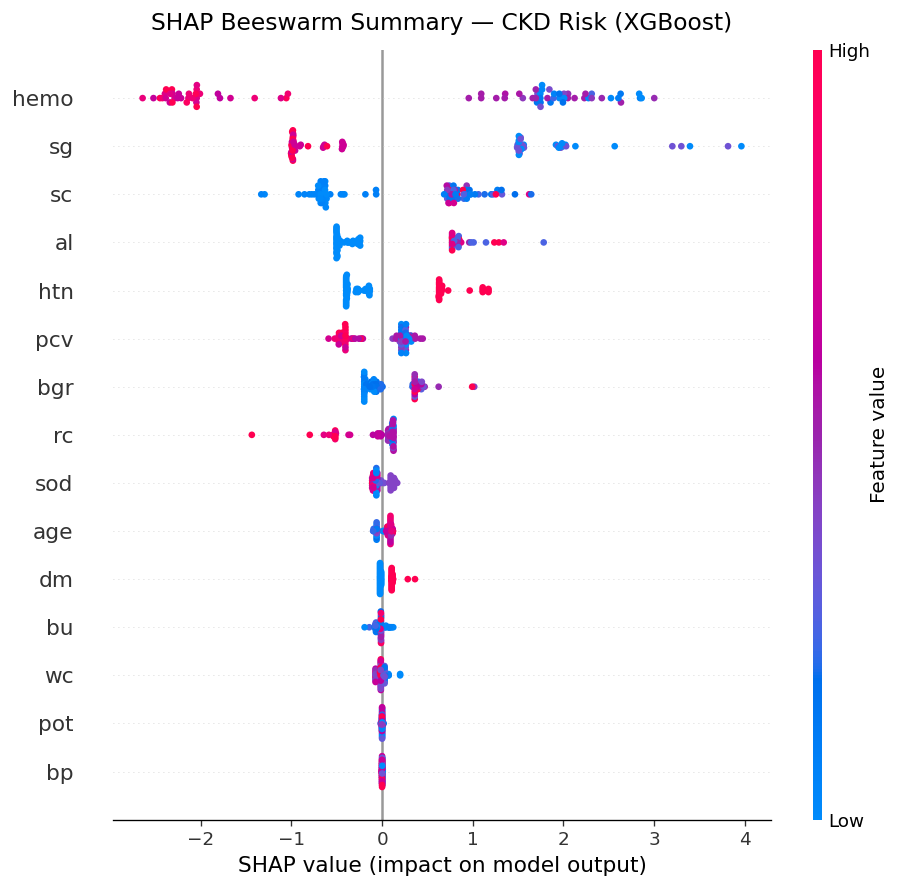

Saved: outputs/shap/ckd/ckd_shap_beeswarm.png


In [8]:
# ── 3a: SHAP Beeswarm Summary Plot (global) ───────────────────────────────────
# Shows direction and magnitude of each feature's impact across all test patients.
# Red = high feature value pushes prediction higher; Blue = low value pushes it lower.

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values_ckd,
    X_ckd_test,
    plot_type='dot',
    max_display=15,
    show=False
)
plt.title('SHAP Beeswarm Summary — CKD Risk (XGBoost)', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('outputs/shap/ckd/ckd_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/shap/ckd/ckd_shap_beeswarm.png')

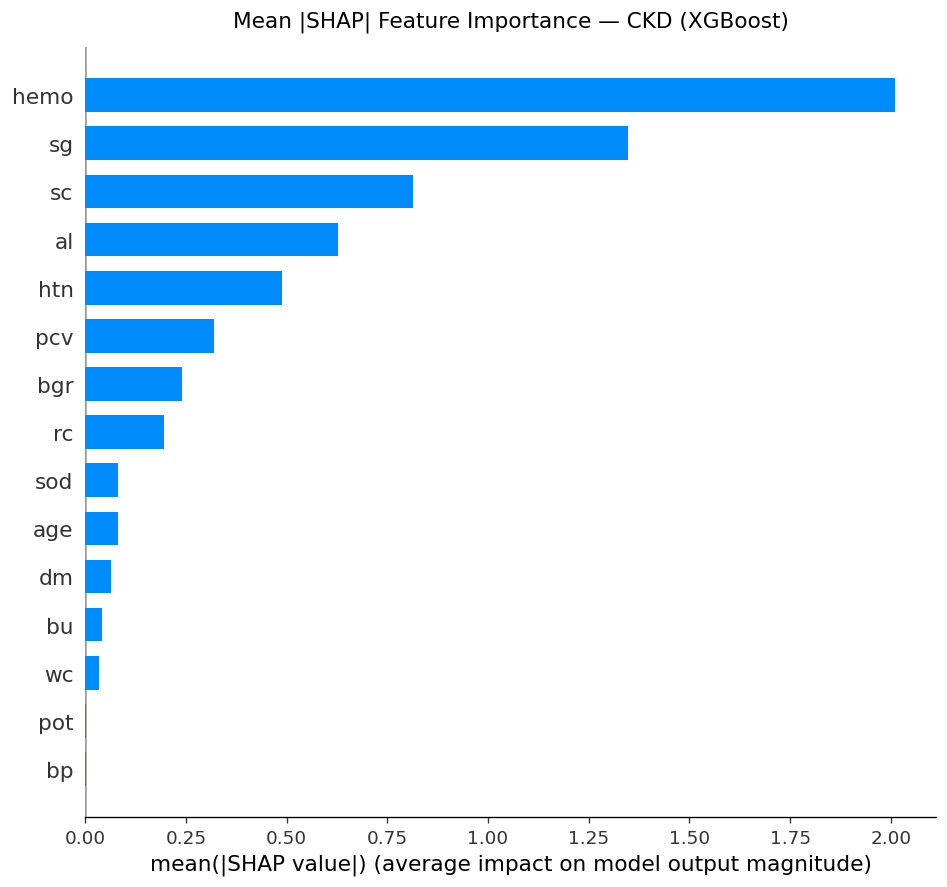

Saved: outputs/shap/ckd/ckd_shap_bar_importance.png


In [9]:
# ── 3b: SHAP Bar Chart — Mean |SHAP| Feature Importance (global) ─────────────
# Ranks features by average absolute SHAP value — a model-level importance summary.

plt.figure(figsize=(9, 6))
shap.summary_plot(
    shap_values_ckd,
    X_ckd_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Mean |SHAP| Feature Importance — CKD (XGBoost)', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('outputs/shap/ckd/ckd_shap_bar_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/shap/ckd/ckd_shap_bar_importance.png')

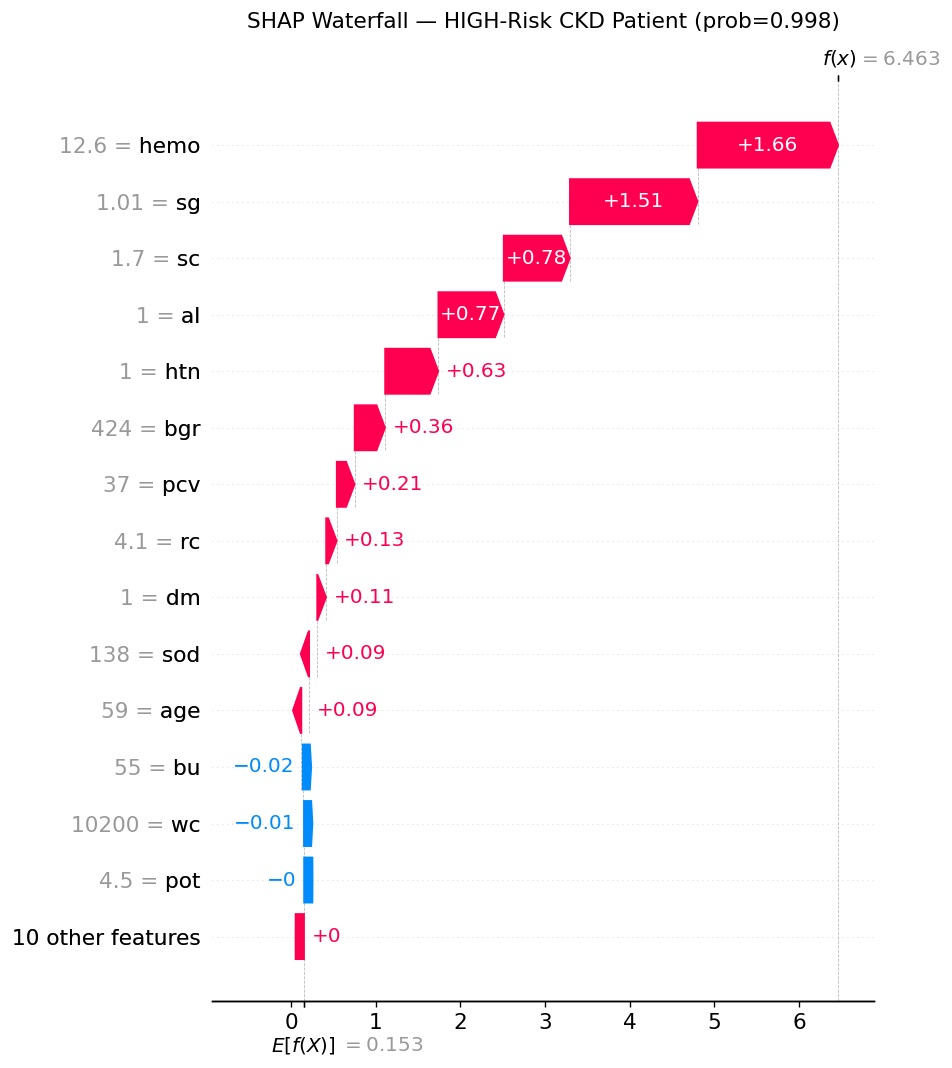

Saved: outputs/shap/ckd/ckd_shap_waterfall_high_risk.png


In [10]:
# ── 3c: SHAP Waterfall — HIGH-Risk CKD Patient ───────────────────────────────
# Waterfall shows how each feature pushes the prediction away from the base value
# for a single patient. Red bars = push toward higher CKD risk; Blue = push lower.

shap_exp_ckd_high = shap.Explanation(
    values=shap_values_ckd[ckd_high_idx],
    base_values=shap_explainer_ckd.expected_value,
    data=X_ckd_test.iloc[ckd_high_idx],
    feature_names=X_ckd.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_ckd_high, max_display=15, show=False)
plt.title(f'SHAP Waterfall — HIGH-Risk CKD Patient (prob={y_ckd_prob[ckd_high_idx]:.3f})',
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('outputs/shap/ckd/ckd_shap_waterfall_high_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/shap/ckd/ckd_shap_waterfall_high_risk.png')

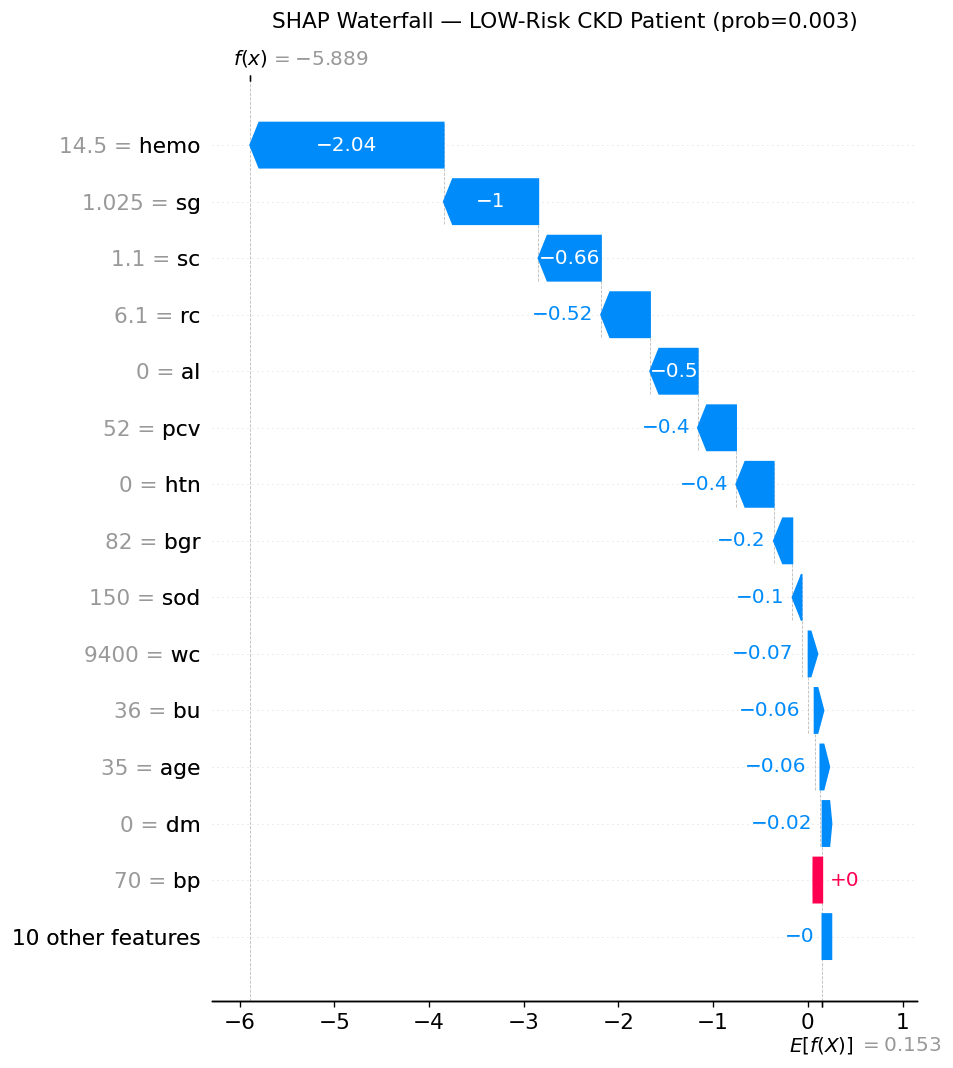

Saved: outputs/shap/ckd/ckd_shap_waterfall_low_risk.png


In [11]:
# ── 3d: SHAP Waterfall — LOW-Risk CKD Patient ────────────────────────────────

shap_exp_ckd_low = shap.Explanation(
    values=shap_values_ckd[ckd_low_idx],
    base_values=shap_explainer_ckd.expected_value,
    data=X_ckd_test.iloc[ckd_low_idx],
    feature_names=X_ckd.columns.tolist()
)

plt.figure(figsize=(10, 6))
shap.waterfall_plot(shap_exp_ckd_low, max_display=15, show=False)
plt.title(f'SHAP Waterfall — LOW-Risk CKD Patient (prob={y_ckd_prob[ckd_low_idx]:.3f})',
          fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('outputs/shap/ckd/ckd_shap_waterfall_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/shap/ckd/ckd_shap_waterfall_low_risk.png')

In [12]:
# ── 3e: SHAP Force Plot — HIGH-Risk CKD Patient (saved as HTML) ──────────────
# The force plot shows the same info as waterfall in a compact horizontal format.

shap.initjs()
force_plot_ckd = shap.force_plot(
    shap_explainer_ckd.expected_value,
    shap_values_ckd[ckd_high_idx],
    X_ckd_test.iloc[ckd_high_idx],
    feature_names=X_ckd.columns.tolist()
)
shap.save_html('outputs/shap/ckd/ckd_shap_force_high_risk.html', force_plot_ckd)
print('Saved: outputs/shap/ckd/ckd_shap_force_high_risk.html')
force_plot_ckd

Saved: outputs/shap/ckd/ckd_shap_force_high_risk.html


Top CKD feature by mean |SHAP|: hemo


<Figure size 1080x600 with 0 Axes>

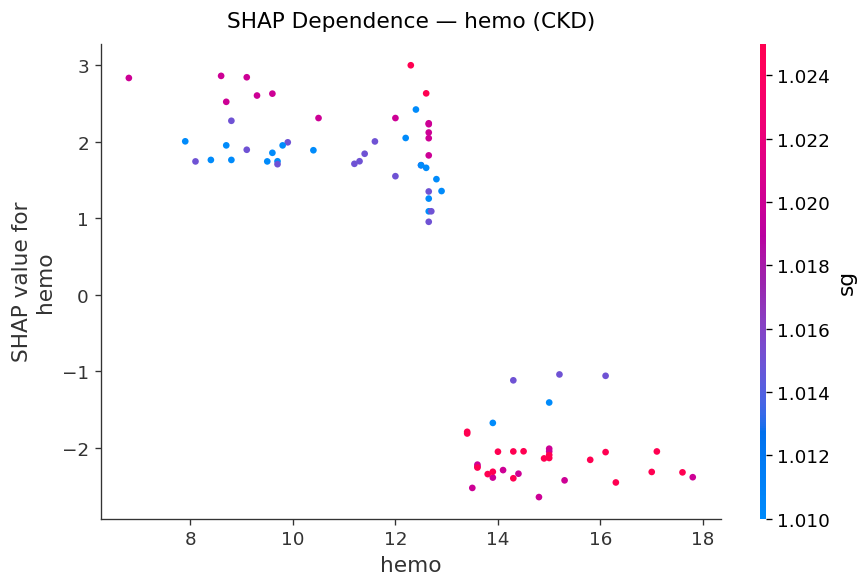

Saved: outputs/shap/ckd/ckd_shap_dependence_hemo.png


In [13]:
# ── 3f: SHAP Dependence Plot — top feature ───────────────────────────────────
# Shows how the top SHAP feature interacts with the second most important feature.

mean_abs_shap_ckd = np.abs(shap_values_ckd).mean(axis=0)
top_feature_ckd = X_ckd.columns[np.argmax(mean_abs_shap_ckd)]
print(f'Top CKD feature by mean |SHAP|: {top_feature_ckd}')

plt.figure(figsize=(9, 5))
shap.dependence_plot(
    top_feature_ckd,
    shap_values_ckd,
    X_ckd_test,
    interaction_index='auto',
    show=False
)
plt.title(f'SHAP Dependence — {top_feature_ckd} (CKD)', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig(f'outputs/shap/ckd/ckd_shap_dependence_{top_feature_ckd}.png',
            dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: outputs/shap/ckd/ckd_shap_dependence_{top_feature_ckd}.png')